<a href="https://colab.research.google.com/github/bellajelly/reinforcement-learning/blob/main/reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium


In [2]:
import gymnasium as gym

env = gym.make("Taxi-v3")
obs, info = env.reset()

print("Initial observation (state):", obs)
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

Initial observation (state): 346
Number of states: 500
Number of actions: 6


In [3]:
import numpy as np

# Initialize Q-table
Q = np.zeros((env.observation_space.n, env.action_space.n))

print("Q-table shape:", Q.shape)
print("Q-table sample row (state 243):", Q[243])

Q-table shape: (500, 6)
Q-table sample row (state 243): [0. 0. 0. 0. 0. 0.]


In [4]:
obs, info = env.reset()

for step in range(5):
    action = env.action_space.sample()
    new_obs, reward, terminated, truncated, info = env.step(action)
    print(f"Step {step+1}: action={action}, new state={new_obs}, reward={reward}, done={terminated}")
    obs = new_obs


Step 1: action=2, new state=347, reward=-1, done=False
Step 2: action=3, new state=327, reward=-1, done=False
Step 3: action=3, new state=327, reward=-1, done=False
Step 4: action=4, new state=327, reward=-10, done=False
Step 5: action=2, new state=347, reward=-1, done=False


In [5]:
# --- Hyperparameters ---
alpha = 0.1       # learning rate
gamma = 0.99      # discount factor
epsilon = 1.0     # exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
n_episodes = 2000

rewards_per_episode = []

for episode in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # --- epsilon-greedy action selection ---
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # --- Bellman update ---
        Q[state, action] = Q[state, action] + alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

        state = next_state
        total_reward += reward

    # --- Decay epsilon ---
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

"My old guess was Q[state, action]. My new, better-informed estimate is the reward I just got, plus the discounted best future I can see from next_state. Nudge my old guess toward that new estimate, scaled by alpha."

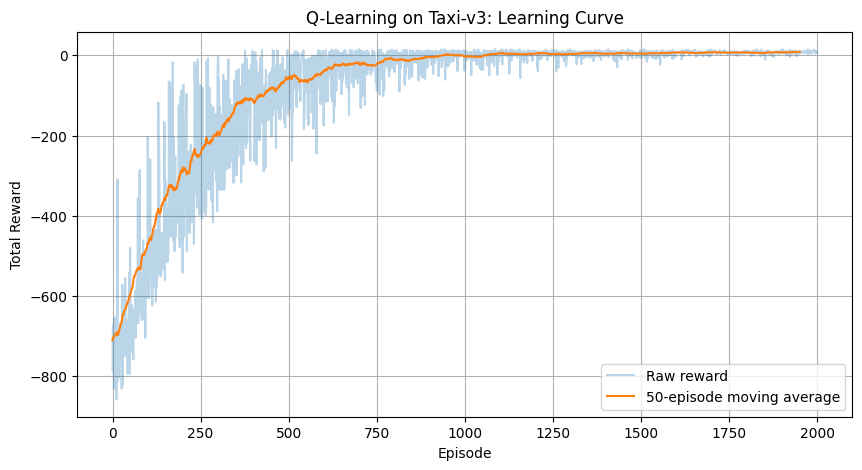

In [6]:
import matplotlib.pyplot as plt

# Calculate moving average with a window of 50 episodes
window = 50
moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(rewards_per_episode, alpha=0.3, label='Raw reward')
plt.plot(moving_avg, label=f'{window}-episode moving average')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning on Taxi-v3: Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

#Reflection

##Challenges in training:

The core challenge is the exploration-exploitation tradeoff. Too much exploration and the agent never uses what it learned. Too little and it gets stuck on a mediocre solution. Additionally, if alpha is too high, Q-values become unstable. If too low, training takes forever to converge. All the hyperparameters interact with each other, so there's no perfect setting — just tradeoffs.

##Hyperparameter effects:

Alpha (learning rate): Higher = faster but unstable. Lower = slower but more reliable.
Gamma (discount factor): Lower = shortsighted agent that ignores long-term rewards. For Taxi-v3 this hurts because the big payoff comes many steps later.
Epsilon decay: Too fast = agent stops exploring before it finds the best strategy, getting stuck in a local optimum.


##Real world applications:

Q-learning and RL are useful anywhere an agent must learn through trial and error, robot navigation, traffic control, game playing, personalized learning systems, and drug dosing optimization in ICUs. Notably, dopamine neurons in the brain appear to encode something very similar to the TD error in our update equation, suggesting the brain itself may implement a form of reinforcement learning.